# Day 16 — Advanced Pandas: Merge, Pivot & Data Cleaning
## Operations Data Analysis
Demonstrating merge operations, pivot tables, and data cleaning  
on simulated production records.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sample_data.csv")

# Calculate OEE
df["availability"] = df["actual_run"] / df["planned"]
df["performance"]  = df["units"] / (df["planned"] * 1.8)
df["quality"]      = df["good_units"] / df["units"]
df["oee"]          = df["availability"] * df["performance"] * df["quality"]

# Convert date column
df["date"] = pd.to_datetime(df["date"])

print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Nulls:\n{df.isnull().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

Dataset: 240 rows × 12 columns
Nulls:
date            0
machine         0
shift           0
actual_run      0
planned         0
units           0
good_units      0
defect_code     0
availability    0
performance     0
quality         0
oee             0
dtype: int64
Duplicates: 0


## Machine Metadata Merge

Enriching production records with department and asset classification.

In [2]:
# Machine metadata
machine_meta = pd.DataFrame({
    "machine":     ["CNC Mill #4", "Press #2", "Assembly Line A", "Weld Station B"],
    "department":  ["Machining", "Stamping", "Assembly", "Welding"],
    "asset_class": ["Critical", "Standard", "Critical", "Standard"]
})

# Left merge
df = pd.merge(df, machine_meta, on="machine", how="left")

print(f"Columns after merge: {list(df.columns)}")
print(df[["machine", "department", "asset_class", "oee"]].head(6))

Columns after merge: ['date', 'machine', 'shift', 'actual_run', 'planned', 'units', 'good_units', 'defect_code', 'availability', 'performance', 'quality', 'oee', 'department', 'asset_class']
           machine department asset_class       oee
0      CNC Mill #4  Machining    Critical  0.785897
1      CNC Mill #4  Machining    Critical  0.753183
2         Press #2   Stamping    Standard  0.759587
3         Press #2   Stamping    Standard  0.613889
4  Assembly Line A   Assembly    Critical  0.895476
5  Assembly Line A   Assembly    Critical  0.836914


## OEE Pivot Table — Machine × Shift

Average OEE by machine center and shift — equivalent to an Excel PivotTable.

OEE by Machine and Shift:
shift              Day  Night
machine                      
Assembly Line A  0.814  0.804
CNC Mill #4      0.788  0.822
Press #2         0.806  0.798
Weld Station B   0.791  0.821


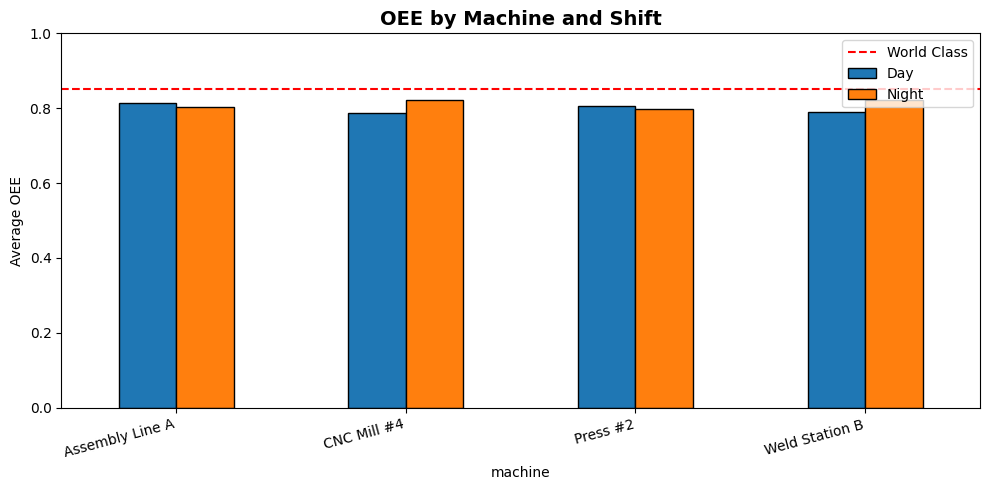

In [3]:
pivot = df.pivot_table(
    values="oee",
    index="machine",
    columns="shift",
    aggfunc="mean"
).round(3)

print("OEE by Machine and Shift:")
print(pivot)

# Visualize pivot as heatmap-style bar chart
pivot.plot(kind="bar", figsize=(10, 5), edgecolor="black")
plt.axhline(y=0.85, color="red", linestyle="--", linewidth=1.5, label="World Class")
plt.title("OEE by Machine and Shift", fontsize=14, fontweight="bold")
plt.ylabel("Average OEE")
plt.ylim(0, 1.0)
plt.xticks(rotation=15, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("oee_pivot_chart.png", dpi=150)
plt.show()

## Performance Ranking

Machines ranked by average OEE — worst performers prioritized for investigation.

In [4]:
machine_avg = df.groupby(["machine", "department", "asset_class"])["oee"]\
                .mean().reset_index()
machine_avg.columns = ["machine", "department", "asset_class", "avg_oee"]
machine_avg["rank"] = machine_avg["avg_oee"].rank(ascending=False).astype(int)
machine_avg = machine_avg.sort_values("avg_oee", ascending=True)
machine_avg["avg_oee"] = machine_avg["avg_oee"].round(3)

print("Machine Performance Ranking — Worst to Best:")
print(machine_avg.to_string(index=False))

Machine Performance Ranking — Worst to Best:
        machine department asset_class  avg_oee  rank
       Press #2   Stamping    Standard    0.802     4
    CNC Mill #4  Machining    Critical    0.805     3
 Weld Station B    Welding    Standard    0.806     2
Assembly Line A   Assembly    Critical    0.809     1


## Key Findings

- Production records enriched with department and asset classification via merge
- Pivot table reveals shift-level OEE variation per machine
- Performance ranking surfaces highest-priority machines for investigation

*Data cleaning confirmed: zero nulls, zero duplicates in simulated dataset*